# GlukoRisk AI - Model Training & ONNX Export
Notebook ini berisi pipeline machine learning lengkap untuk melatih model klasifikasi risiko diabetes menggunakan dataset BRFSS2015, evaluasi performa model, konversi ke format ONNX (`.onnx`), serta verifikasi inferensi menggunakan ONNX Runtime.

## 1. Import Libraries & Setup
Mengimpor library yang dibutuhkan untuk pengolahan data, machine learning, visualisasi, dan ekspor ONNX.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix, 
    accuracy_score,
    roc_curve
)

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt

# Setup visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Dataset
Memuat dataset `diabetes_binary_5050split_health_indicators_BRFSS2015.csv` dari folder `../data/raw/`.

In [2]:
data_path = "../data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(data_path)

print(f"Dimensi dataset: {df.shape[0]:,} baris, {df.shape[1]} kolom")
print(f"Distribusi Target (Diabetes_binary):")
print(df['Diabetes_binary'].value_counts())
df.head()

Dimensi dataset: 70,692 baris, 22 kolom
Distribusi Target (Diabetes_binary):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 3. Data Splitting (Features & Target)
Memisahkan fitur `X` dan target `y` (`Diabetes_binary`), kemudian membagi data menjadi Train (80%) dan Test (20%) dengan `stratify=y` dan `random_state=42`.

In [3]:
# Pisahkan fitur dan target
X = df.drop(columns=['Diabetes_binary']).astype(np.float32)
y = df['Diabetes_binary'].astype(int)

feature_names = list(X.columns)
print(f"Total fitur: {len(feature_names)}")
print(f"Daftar fitur: {feature_names}")

# Split Train (80%) dan Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nUkuran X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Ukuran X_test : {X_test.shape}, y_test : {y_test.shape}")

Total fitur: 21
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Ukuran X_train: (56553, 21), y_train: (56553,)
Ukuran X_test : (14139, 21), y_test : (14139,)


## 4. Model Training & Evaluation
Melatih model `RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)` dan mengevaluasi performanya pada test set.

In [4]:
# 1. Inisialisasi & Fit Model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2. Prediksi pada Test Set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 3. Evaluasi Metrik
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print(f"Akurasi Test Set : {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC Score    : {roc_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

Akurasi Test Set : 0.7492 (74.92%)
ROC-AUC Score    : 0.8283

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.78      0.70      0.74      7070
    Diabetic (1)       0.73      0.80      0.76      7069

        accuracy                           0.75     14139
       macro avg       0.75      0.75      0.75     14139
    weighted avg       0.75      0.75      0.75     14139



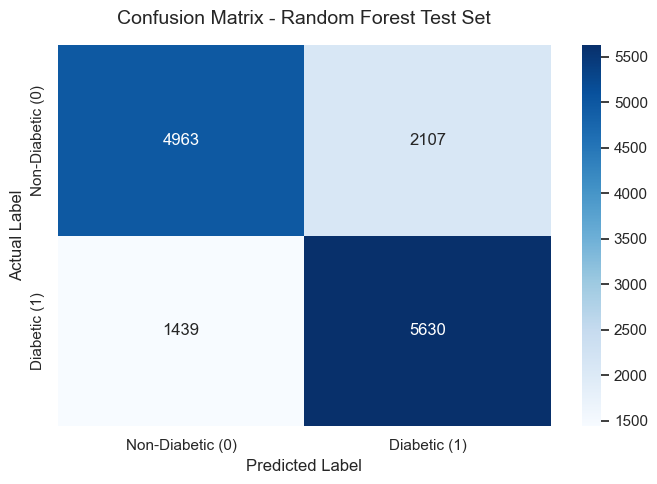

In [5]:
# Visualisasi Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], 
    yticklabels=["Non-Diabetic (0)", "Diabetic (1)"],
    cbar=True
)
plt.title("Confusion Matrix - Random Forest Test Set", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Export Model to ONNX
Mengonversi model terlatih ke format ONNX menggunakan `skl2onnx` dengan input tensor float32 berbentuk `[None, 21]`, lalu menyimpannya ke `../models/diabetes_model.onnx`.

In [6]:
# Tentukan input tensor float32 dengan shape [None, 21]
num_features = X.shape[1]
initial_type = [('float_input', FloatTensorType([None, num_features]))]

# Konversi model scikit-learn ke ONNX
onnx_model = convert_sklearn(
    rf_model, 
    initial_types=initial_type, 
    target_opset=15,
    options={type(rf_model): {'zipmap': False}}
)

# Simpan ke direktori ../models
os.makedirs("../models", exist_ok=True)
onnx_path = "../models/diabetes_model.onnx"

with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Model berhasil diekspor ke format ONNX!")
print(f"Path file   : {os.path.abspath(onnx_path)}")
print(f"Ukuran file : {os.path.getsize(onnx_path) / (1024 * 1024):.2f} MB")

Model berhasil diekspor ke format ONNX!
Path file   : z:\Projects\GlukoRisk_AI\models\diabetes_model.onnx
Ukuran file : 12.80 MB


## 6. Inference Verification (ONNX Runtime)
Memuat model `diabetes_model.onnx` menggunakan `onnxruntime.InferenceSession` dan melakukan inferensi uji coba pada 1 baris sampel data uji untuk memvalidasi label prediksi dan probabilitas risiko.

In [7]:
# 1. Inisialisasi ONNX Runtime Inference Session
sess = rt.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])

input_name = sess.get_inputs()[0].name
output_names = [out.name for out in sess.get_outputs()]

print(f"Input Name   : {input_name}")
print(f"Output Names : {output_names}")
print(f"Input Shape  : {sess.get_inputs()[0].shape}")
print(f"Input Type   : {sess.get_inputs()[0].type}")

# 2. Ambil 1 baris sampel dari data uji
sample_input = X_test.iloc[0:1].values.astype(np.float32)
sample_actual = y_test.iloc[0]

# 3. Jalankan inferensi ONNX
onnx_outputs = sess.run(None, {input_name: sample_input})
predicted_label = onnx_outputs[0][0]
predicted_probabilities = onnx_outputs[1][0]

print("\n" + "=" * 55)
print("HASIL VERIFIKASI INFERENSI ONNX:")
print("=" * 55)
print(f"Actual Label               : {sample_actual}")
print(f"Predicted Label (ONNX)     : {predicted_label}")
print(f"Probabilitas [Class 0, 1]  : {predicted_probabilities}")
print(f"Skor Risiko Diabetes       : {predicted_probabilities[1] * 100:.2f}%")
print("=" * 55)

# 4. Validasi konsistensi dengan Scikit-Learn
sklearn_pred = rf_model.predict(sample_input)[0]
sklearn_proba = rf_model.predict_proba(sample_input)[0]
print(f"Sklearn Pred Label         : {sklearn_pred}")
print(f"Sklearn Probabilities      : {sklearn_proba}")

np.testing.assert_allclose(predicted_probabilities, sklearn_proba, rtol=1e-4, atol=1e-4)
print("\nVerifikasi Sukses: Output ONNX identik dengan output Scikit-Learn!")

Input Name   : float_input
Output Names : ['label', 'probabilities']
Input Shape  : [None, 21]
Input Type   : tensor(float)

HASIL VERIFIKASI INFERENSI ONNX:
Actual Label               : 1
Predicted Label (ONNX)     : 1
Probabilitas [Class 0, 1]  : [0.10356367 0.89643633]
Skor Risiko Diabetes       : 89.64%
Sklearn Pred Label         : 1
Sklearn Probabilities      : [0.10356368 0.89643632]

Verifikasi Sukses: Output ONNX identik dengan output Scikit-Learn!


c:\Users\dzaki\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\dzaki\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
